In [36]:
import pandas as pd          # Data manipulation and analysis
import numpy as np           # Numerical computations and arrays
import matplotlib.pyplot as plt   # Data visualization / plotting graphs

from sklearn.model_selection import train_test_split  # Split dataset into training and testing sets
from sklearn.linear_model import LinearRegression     # Linear regression model for prediction
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # Model evaluation metrics
from sklearn.preprocessing import StandardScaler      # Feature scaling (standardization)
from sklearn.cluster import KMeans                    # K-Means clustering algorithm

In [37]:
#load data set
df = pd.read_csv(r"C:\Users\hanaa\Downloads\Real estate dataset (1).csv")
df.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [38]:
print(df.shape)        # rows and columns

(414, 8)


In [39]:
print(df.columns)      # column names

Index(['No', 'X1 transaction date', 'X2 house age',
       'X3 distance to the nearest MRT station',
       'X4 number of convenience stores', 'X5 latitude', 'X6 longitude',
       'Y house price of unit area'],
      dtype='object')


In [40]:
print(df.isnull().sum())  # missing values

No                                        0
X1 transaction date                       0
X2 house age                              0
X3 distance to the nearest MRT station    0
X4 number of convenience stores           0
X5 latitude                               0
X6 longitude                              0
Y house price of unit area                0
dtype: int64


In [41]:
df.describe()          # statistics

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
count,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000
mean,207.500000,2013.148971,17.712560,1083.885689,4.094203,24.969030,121.533361,37.980193
std,119.655756,0.281967,11.392485,1262.109595,2.945562,0.012410,0.015347,13.606488
min,1.000000,2012.667000,0.000000,23.382840,0.000000,24.932070,121.473530,7.600000
25%,104.250000,2012.917000,9.025000,289.324800,1.000000,24.963000,121.528085,27.700000
50%,207.500000,2013.167000,16.100000,492.231300,4.000000,24.971100,121.538630,38.450000
75%,310.750000,2013.417000,28.150000,1454.279000,6.000000,24.977455,121.543305,46.600000
max,414.000000,2013.583000,43.800000,6488.021000,10.000000,25.014590,121.566270,117.500000


In [42]:
# Task A3: Rename columns

In [43]:
df = df.rename(columns={
"X1 transaction date": "date",
"X2 house age": "age",
"X3 distance to the nearest MRT station": "mrt_distance",
"X4 number of convenience stores": "stores",
"X5 latitude": "lat",
"X6 longitude": "lon",
"Y house price of unit area": "price_unit"
})

df.head()

,No,date,age,mrt_distance,stores,lat,lon,price_unit
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


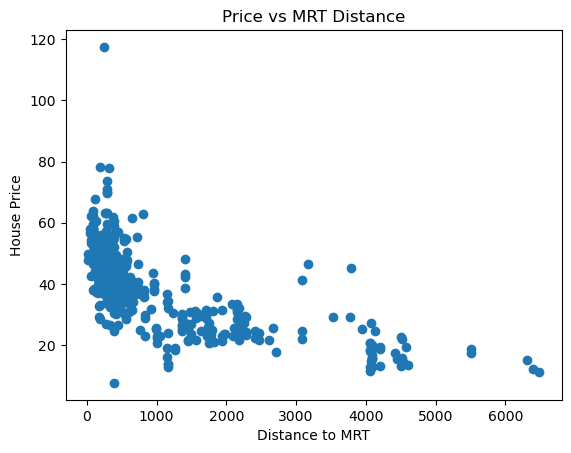

In [44]:
# Part B — Exploratory Data Analysis
# Task B1: Scatter plots
# Price vs MRT distance

plt.figure()
plt.scatter(df["mrt_distance"], df["price_unit"])
plt.xlabel("Distance to MRT")
plt.ylabel("House Price")
plt.title("Price vs MRT Distance")
plt.show()


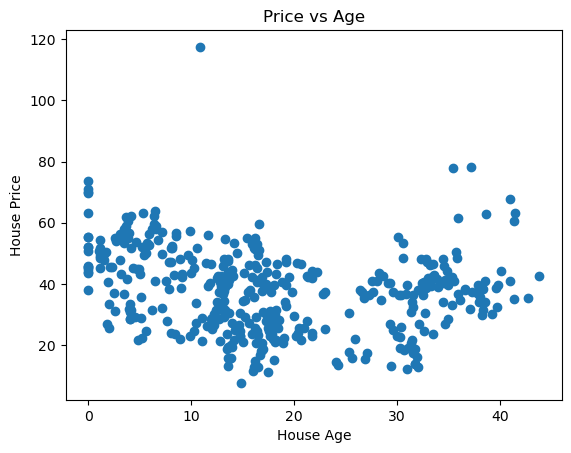

In [45]:
#Price vs house age
plt.figure()
plt.scatter(df["age"], df["price_unit"])
plt.xlabel("House Age")
plt.ylabel("House Price")
plt.title("Price vs Age")
plt.show()

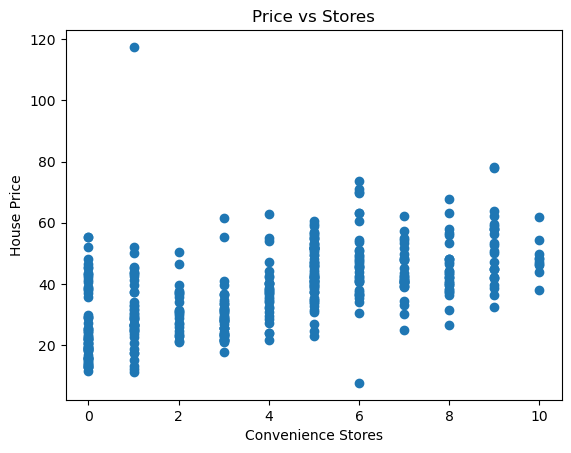

In [46]:
# Price vs stores
plt.figure()
plt.scatter(df["stores"], df["price_unit"])
plt.xlabel("Convenience Stores")
plt.ylabel("House Price")
plt.title("Price vs Stores")
plt.show()

In [47]:
#Task B2: Compute correlation matrix and identify strongest relationship.
df[["date","age","mrt_distance","stores","lat","lon","price_unit"]].corr()

,date,age,mrt_distance,stores,lat,lon,price_unit
date,1.000000,0.017549,0.060880,0.009635,0.035058,-0.041082,0.087491
age,0.017549,1.000000,0.025622,0.049593,0.054420,-0.048520,-0.210567
mrt_distance,0.060880,0.025622,1.000000,-0.602519,-0.591067,-0.806317,-0.673613
stores,0.009635,0.049593,-0.602519,1.000000,0.444143,0.449099,0.571005
lat,0.035058,0.054420,-0.591067,0.444143,1.000000,0.412924,0.546307
lon,-0.041082,-0.048520,-0.806317,0.449099,0.412924,1.000000,0.523287
price_unit,0.087491,-0.210567,-0.673613,0.571005,0.546307,0.523287,1.000000


In [48]:
#⃣ Part C — Simple Linear Regression
# Use only MRT distance

X = df[["mrt_distance"]]
y = df["price_unit"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_1 = LinearRegression()
model_1.fit(X_train, y_train)

print("Intercept:", model_1.intercept_)
print("Coefficient:", model_1.coef_[0])
 

Intercept: 46.24269004533652
Coefficient: -0.007409512934932927


In [49]:
# Regression model results:
# Intercept: 46.24
# Coefficient: -0.00741

# The intercept represents the predicted house price 
# when the distance to the MRT station is 0 meters.

# The coefficient shows how the house price changes with distance:
# For every 1 meter increase from the MRT, the predicted price decreases by ~0.0074 units.

# Negative coefficient means:
#   - Houses closer to MRT stations are usually more expensive.
#   - Houses further away are usually cheaper.

# This relationship makes sense in real life because proximity to public transport increases property value.

# Conclusion: The model has learned a meaningful and reasonable relationship for this feature.

In [50]:
#Task C2: Interpretation
#The negative coefficient indicates that as the distance from the MRT station increases, house prices tend to decrease.

In [52]:
#Task C3: Model evaluation
pred = model_1.predict(X_test)

mae = mean_absolute_error(y_test, pred)
#rmse = mean_squared_error(y_test, pred, squared=False) code in lab
rmse = np.sqrt(mean_squared_error(y_test, pred))  # works everywhere
r2 = r2_score(y_test, pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

 

MAE: 6.920972703573579
RMSE: 8.79454329599807
R2: 0.5389597665019772


In [53]:
# MAE: 6.92 → good
# RMSE: 8.79 → good
# R²: 0.539 → moderate
#this tells you predictions are reasonably accurate but there’s room for improvement.
# Model Evaluation Reference:
# 
# 1️⃣ R² (Coefficient of Determination)
# R² value   Quality
# < 0.3      poor
# 0.3–0.6    moderate
# 0.6–0.8    good
# 0.8+       very strong
# 
# 2️⃣ RMSE (Root Mean Squared Error)
# Assuming house prices ~20–60 units, lower RMSE is better:
# RMSE value Quality
# >15        poor
# 10–15      moderate
# 5–10       good
# <5         very strong
# 
# 3️⃣ MAE (Mean Absolute Error)
# Lower MAE is better:
# MAE value  Quality
# >12        poor
# 8–12       moderate
# 4–8        good
# <4         very strong

C:\Users\hanaa\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


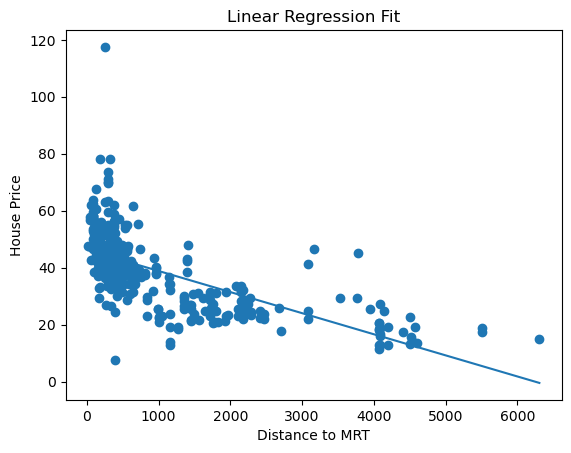

In [16]:
plt.figure()
plt.scatter(X_train, y_train)

x_line = np.linspace(X_train.min().values[0],
                     X_train.max().values[0], 200).reshape(-1,1)

plt.plot(x_line, model_1.predict(x_line))

plt.xlabel("Distance to MRT")
plt.ylabel("House Price")
plt.title("Linear Regression Fit")
plt.show()

In [17]:

df = pd.read_csv(r"C:\Users\hanaa\Downloads\Real estate dataset (1).csv")

# Rename columns for easier use
df = df.rename(columns={
    "X1 transaction date": "date",
    "X2 house age": "age",
    "X3 distance to the nearest MRT station": "mrt_distance",
    "X4 number of convenience stores": "stores",
    "X5 latitude": "lat",
    "X6 longitude": "lon",
    "Y house price of unit area": "price_unit"
})

# Select the features (independent variables) we want to use for prediction
features = ["date","age","mrt_distance","stores","lat","lon"]

# X is the feature matrix, y is the target variable (price per unit)
X = df[features]
y = df["price_unit"]

# Split the data into training and testing sets
# 80% for training, 20% for testing, with a fixed random seed for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Initialize a multiple linear regression model
model_multi = LinearRegression()

# Fit/train the model on the training data
model_multi.fit(X_train, y_train)

# Predict the target variable for the test set
pred = model_multi.predict(X_test)

# Evaluate the model performance using RMSE (Root Mean Squared Error)
#print("RMSE:", np.sqrt(mean_squared_error(y_test, pred))

# Evaluate the model performance using R-squared (coefficient of determination)
#print("R2:", r2_score(y_test, pred))

# Compute RMSE manually (works in all sklearn versions)
mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)
print("RMSE:", rmse)

# Compute R-squared (proportion of variance explained by the model)
r2 = r2_score(y_test, pred)
print("R2:", r2)

RMSE: 7.314753524521961
R2: 0.6810580555095684


In [18]:
# Print coefficients
#positive coefficient → increases price
#negative coefficient → decreases price

coef_table = pd.Series(model_multi.coef_, index=features).sort_values()
print(coef_table)

print("Intercept:", model_multi.intercept_)

lon             -29.492591
age              -0.270791
mrt_distance     -0.004759
stores            1.091425
date              5.440742
lat             229.043054
dtype: float64
Intercept: -13044.231917160501


In [19]:
#Part E — Normal Equation
#This computes regression using matrix algebra instead of sklearn.
X = df[features].values
y = df["price_unit"].values.reshape(-1,1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train_b = np.c_[np.ones((len(X_train),1)), X_train]

theta = np.linalg.inv(X_train_b.T @ X_train_b) @ X_train_b.T @ y_train

theta[:5]

array([[-1.30442323e+04],
       [ 5.44074200e+00],
       [-2.70791490e-01],
       [-4.75863891e-03],
       [ 1.09142527e+00]])

In [20]:
#Part F: Gradient Descent
#Task F1: Implement batch gradient descent.
def batch_gradient_descent(X, y, learning_rate=0.01, epochs=2000):
    m, n = X.shape
    X_b = np.c_[np.ones((m, 1)), X]
    theta   = np.zeros((n + 1, 1))
    history = []
    
    for epoch in range(epochs):
        gradients = (2/m) * X_b.T @ (X_b @ theta - y)
        theta = theta - learning_rate * gradients
        
        if epoch % 100 == 0:
            rmse = np.sqrt(((X_b @ theta - y) ** 2).mean())
            history.append((epoch, rmse))
    return theta, history

In [24]:
theta_ns, hist_ns = batch_gradient_descent(X_train, y_train, learning_rate=1e-8, epochs=5000)
hist_ns[-5:]



C:\Users\hanaa\AppData\Local\Temp\ipykernel_19284\2602493734.py:10: RuntimeWarning: overflow encountered in matmul
  gradients = (2/m) * X_b.T @ (X_b @ theta - y)
C:\Users\hanaa\AppData\Local\Temp\ipykernel_19284\2602493734.py:11: RuntimeWarning: invalid value encountered in subtract
  theta = theta - learning_rate * gradients


[(4500, np.float64(nan)),
 (4600, np.float64(nan)),
 (4700, np.float64(nan)),
 (4800, np.float64(nan)),
 (4900, np.float64(nan))]

In [22]:
from sklearn.preprocessing import PolynomialFeatures
#CODE BASED ON LAB BUT NOT WORKING
# Polynomial degree 2 on MRT distance
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(df[["mrt_distance"]])

X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=42)
model_poly = LinearRegression()
model_poly.fit(X_train, y_train)

pred_poly = model_poly.predict(X_test)
print("RMSE (Poly degree 2):", mean_squared_error(y_test, pred_poly, squared=False))
print("R2 (Poly degree 2):", r2_score(y_test, pred_poly))

TypeError: got an unexpected keyword argument 'squared'

In [23]:
from sklearn.preprocessing import PolynomialFeatures
 #chat gpt
# Polynomial degree 2 on MRT distance
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(df[["mrt_distance"]])

X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=42)
model_poly = LinearRegression()
model_poly.fit(X_train, y_train)

rmse = np.sqrt(mean_squared_error(y_test, pred_poly)) #chnages made here
print("RMSE (Poly degree 2):", rmse) #changes made here
print("R2 (Poly degree 2):", r2_score(y_test, pred_poly)) # chnages made here

RMSE (Poly degree 2): 8.32846538029234
R2 (Poly degree 2): 0.5865317046762943


C:\Users\hanaa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\hanaa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\hanaa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\hanaa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Window

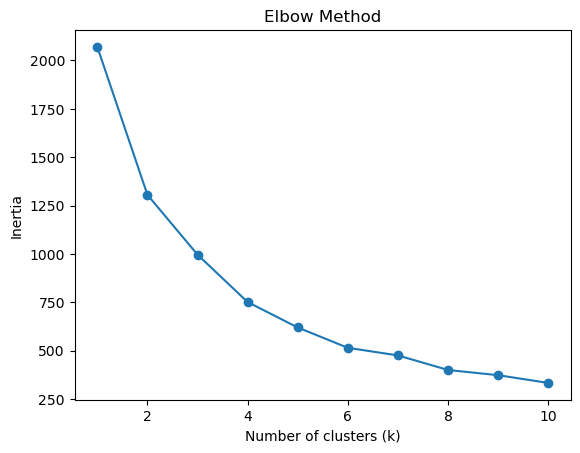

C:\Users\hanaa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


,mrt_distance,stores,lat,lon,age
cluster,,,,,
0,2992.959965,1.558140,24.954235,121.508749,18.039535
1,631.600086,4.260090,24.971921,121.540222,10.362780
2,480.831420,5.819048,24.975009,121.538949,33.054286


In [26]:
# Import the KMeans clustering algorithm from sklearn
from sklearn.cluster import KMeans

# Select the features (columns) we want to use for clustering
cluster_features = ["mrt_distance","stores","lat","lon","age"]

# Standardize (scale) the data so all features are on a similar scale
# This prevents large values (like distance) from dominating the clustering
Xc = StandardScaler().fit_transform(df[cluster_features])

# Create an empty list to store inertia values for different numbers of clusters
inertia = []

# Loop through different values of k (number of clusters) from 1 to 10
for k in range(1, 11):

    # Create a KMeans model with k clusters
    kmeans = KMeans(n_clusters=k, random_state=42)

    # Fit the model to the scaled data
    kmeans.fit(Xc)

    # Store the inertia (measure of clustering error) for this k
    inertia.append(kmeans.inertia_)

# Plot the elbow graph to help decide the best number of clusters
plt.plot(range(1,11), inertia, marker='o')

# Label the x-axis
plt.xlabel("Number of clusters (k)")

# Label the y-axis
plt.ylabel("Inertia")

# Add a title to the graph
plt.title("Elbow Method")

# Display the plot
plt.show()

# Create the final KMeans model using 3 clusters (chosen from elbow method)
kmeans_final = KMeans(n_clusters=3, random_state=42)

# Fit the model and assign each row to a cluster, then store the cluster number in a new column
df["cluster"] = kmeans_final.fit_predict(Xc)

# Group the dataset by cluster and calculate the average value of each feature
# This helps understand the characteristics of each cluster
df.groupby("cluster")[cluster_features].mean()

In [27]:
features = ["date","age","mrt_distance","stores"]

# X is the feature matrix, y is the target variable (price per unit)
X = df[features]
y = df["price_unit"]

# Split the data into training and testing sets
# 80% for training, 20% for testing, with a fixed random seed for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Initialize a multiple linear regression model
model_multi = LinearRegression()

# Fit/train the model on the training data
model_multi.fit(X_train, y_train)

# Predict the target variable for the test set
pred = model_multi.predict(X_test)

# Evaluate the model performance using RMSE (Root Mean Squared Error)
#print("RMSE:", np.sqrt(mean_squared_error(y_test, pred))

# Evaluate the model performance using R-squared (coefficient of determination)
#print("R2:", r2_score(y_test, pred))

# Compute RMSE manually (works in all sklearn versions)
mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)
print("RMSE:", rmse)

# Compute R-squared (proportion of variance explained by the model)
r2 = r2_score(y_test, pred)
print("R2:", r2)

RMSE: 7.49107402832714
R2: 0.6654966883840013


RMSE: 7.314753524521661
R2: 0.6810580555095946

Model Coefficients:
        Feature  Coefficient
0          date     1.529631
1           age    -3.062694
2  mrt_distance    -5.786926
3        stores     3.218873
4           lat     2.855108
5           lon    -0.441009

Intercept: 38.39154078549889


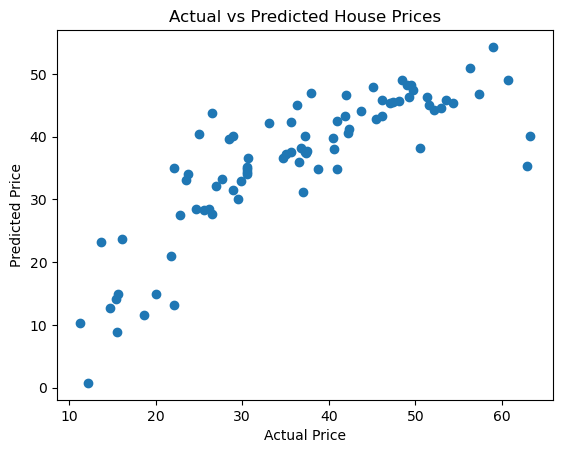

In [28]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# -----------------------------
# Load dataset
# -----------------------------
df = pd.read_csv(r"C:\Users\hanaa\Downloads\Real estate dataset (1).csv")

# Rename columns for easier use
df = df.rename(columns={
    "X1 transaction date": "date",
    "X2 house age": "age",
    "X3 distance to the nearest MRT station": "mrt_distance",
    "X4 number of convenience stores": "stores",
    "X5 latitude": "lat",
    "X6 longitude": "lon",
    "Y house price of unit area": "price_unit"
})

# -----------------------------
# Select features and target
# -----------------------------

# Independent variables (features)
features = ["date","age","mrt_distance","stores","lat","lon"]

# Feature matrix
X = df[features]

# Target variable
y = df["price_unit"]

# -----------------------------
# Split dataset
# -----------------------------

# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# Feature scaling
# -----------------------------

# Scaling helps when features have very different ranges
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -----------------------------
# Train regression model
# -----------------------------

# Initialize multiple linear regression model
model = LinearRegression()

# Train model using training data
model.fit(X_train_scaled, y_train)

# -----------------------------
# Make predictions
# -----------------------------

# Predict house prices on test data
pred = model.predict(X_test_scaled)

# -----------------------------
# Evaluate model
# -----------------------------

# Compute RMSE
rmse = np.sqrt(mean_squared_error(y_test, pred))
print("RMSE:", rmse)

# Compute R²
r2 = r2_score(y_test, pred)
print("R2:", r2)

# -----------------------------
# Interpret coefficients
# -----------------------------

# Create table of feature coefficients
coef_table = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_
})

print("\nModel Coefficients:")
print(coef_table)

# Print intercept
print("\nIntercept:", model.intercept_)

# -----------------------------
# Optional: visualize predictions
# -----------------------------

plt.figure()

# Scatter plot of actual vs predicted values
plt.scatter(y_test, pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted House Prices")

plt.show()

In [34]:
# Gradient Descent
#implement
def batch_gradient_descent(X, y, learning_rate=0.01, epochs=2000):
    m, n = X.shape
    X_b = np.c_[np.ones((m, 1)), X]
    theta = np.zeros((n + 1, 1))
    history = []

    for epoch in range(epochs):
        gradients = (2/m) * X_b.T @ (X_b @ theta - y)
        theta = theta - learning_rate * gradients

        if epoch % 100 == 0:
            rmse = np.sqrt(((X_b @ theta - y) ** 2).mean())
            history.append((epoch, rmse))

    return theta, history

#Run Gradient Descent WITHOUT Scaling (you already did)
# Run gradient descent without feature scaling
# Convert training data to NumPy arrays
X_train_np = X_train.values
y_train_np = y_train.values.reshape(-1,1)

# Run gradient descent without scaling
theta_ns, hist_ns = batch_gradient_descent(
    X_train_np,
    y_train_np,
    learning_rate=0.00000001,
    epochs=5000
)

# Check last values
hist_ns[-5:]


[(4500, np.float64(10.330462357217538)),
 (4600, np.float64(10.33028173288304)),
 (4700, np.float64(10.33010119334774)),
 (4800, np.float64(10.329920738571214)),
 (4900, np.float64(10.32974036851305))]

In [31]:
#Apply Feature Scaling
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Fit scaler on training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Convert y to numpy array if needed
y_train_np = y_train.values.reshape(-1,1)

In [32]:
# Run gradient descent again using scaled features
theta_s, hist_s = batch_gradient_descent(
    X_train_scaled,
    y_train_np,
    learning_rate=0.01,
    epochs=2000
)

# Check last RMSE values
hist_s[-5:]

[(1500, np.float64(9.116667365203865)),
 (1600, np.float64(9.116663683367031)),
 (1700, np.float64(9.116661750056487)),
 (1800, np.float64(9.116660734886809)),
 (1900, np.float64(9.116660201827386))]

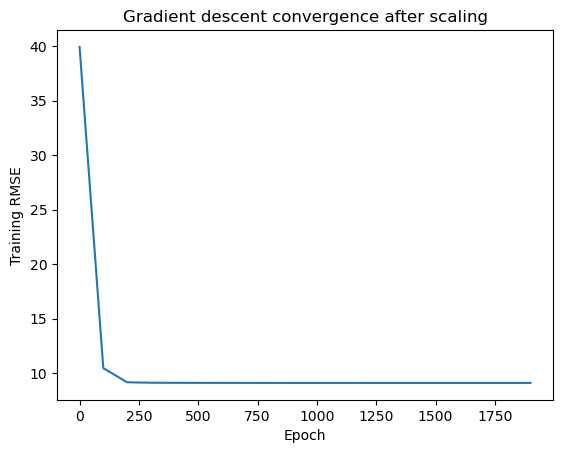

In [33]:
plt.figure()

plt.plot([h[0] for h in hist_s], [h[1] for h in hist_s])

plt.xlabel("Epoch")
plt.ylabel("Training RMSE")
plt.title("Gradient descent convergence after scaling")

plt.show()